# Análisis Exploratorio de Datos (EDA) Spotify

* Objetivo

El presente notebook tiene como objetivo realizar un Análisis Exploratorio de Datos (EDA, *Exploratory Data Analysis*) sobre el conjunto de datos correspondiente a pistas musicales de Spotify.

El análisis busca obtener una visión general de la estructura del dataset, evaluar su calidad, identificar características relevantes de las variables y analizar sus distribuciones mediante técnicas estadísticas y visualizaciones.

Los resultados obtenidos durante esta etapa servirán como base para las posteriores tareas de ingeniería de características, preprocesamiento y construcción de modelos de aprendizaje automático.

---

Consideraciones para la ejecución en Google Colab

En caso de ejecutar este notebook utilizando Google Colab, puede ser necesario instalar previamente la dependencia `fg-data-profiling`.

La instalación debe realizarse desde la terminal de Colab:

```bash
pip install fg-data-profiling

In [ ]:
""""
EN LA TERMINAL DE COLAB: pip install fg-data-profiling
solo funciona con .xlsx

import pandas as pd
import data_profiling
from data_profiling import ProfileReport
df=pd.read_csv("Spotify_Corregido.xlsx")
df = df.drop(columns=['Unnamed: 0'])

profile = ProfileReport(df, title="Reporte de Perfilado de Datos")
profile.to_file("/reports/Informe_Ejecutivo.html")

"""

Nota: Esta sección corresponde únicamente a una alternativa de ejecución en Google Colab. Si el entorno de ejecución ya dispone de las dependencias requeridas, puede omitirse.

---

## Importación y configuración del entorno

Se importan las bibliotecas necesarias para la manipulación de datos, generación de visualizaciones y configuración de las rutas del proyecto.

Además, se incorpora el directorio padre a sys.path para permitir la utilización de módulos y funciones desarrollados localmente dentro del repositorio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))


---

## Carga del dataset

El conjunto de datos utilizado corresponde al dataset de Spotify en su versión cruda, previo a la aplicación de las etapas de limpieza y transformación.

In [ ]:
df=pd.read_csv("../dataset/spotify_crudo.csv")

El archivo se encuentra almacenado en el directorio `/dataset` del proyecto y constituye el punto de partida para el análisis exploratorio.

---

## Vision General del Dataset

Esta etapa tiene como finalidad obtener una primera caracterización del conjunto de datos, considerando su estructura, dimensionalidad, tipos de datos y cardinalidad de las variables.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113422 entries, 0 to 113421
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113422 non-null  str    
 1   album_name        113422 non-null  str    
 2   track_name        113422 non-null  str    
 3   popularity        113422 non-null  float64
 4   duration_ms       113422 non-null  int64  
 5   explicit          113422 non-null  bool   
 6   danceability      113422 non-null  float64
 7   energy            113422 non-null  float64
 8   key               113422 non-null  int64  
 9   loudness          113422 non-null  float64
 10  mode              113422 non-null  int64  
 11  speechiness       113422 non-null  float64
 12  acousticness      113422 non-null  float64
 13  instrumentalness  113422 non-null  float64
 14  liveness          113422 non-null  float64
 15  valence           113422 non-null  float64
 16  tempo             113422 non-nu

In [5]:
df.nunique()

artists             31437
album_name          46589
track_name          73608
popularity            101
duration_ms         46354
explicit                2
danceability          904
energy               2083
key                    12
loudness            15098
mode                    2
speechiness           838
acousticness         5061
instrumentalness     4468
liveness             1261
valence              1790
tempo               45354
time_signature          1
track_genre           114
dtype: int64

Se obtiene la cantidad de valores únicos presentes en cada variable.

El análisis de cardinalidad resulta especialmente relevante para las variables categóricas, ya que permite identificar aquellas que poseen una gran cantidad de categorías y que, por lo tanto, podrían requerir estrategias de codificación específicas durante el preprocesamiento.

In [11]:
df['key'].unique()

array([ 1,  0,  2,  6, 11,  8,  4,  7,  3, 10,  5,  9])

Se inspeccionan explícitamente los valores únicos de la variable key, correspondiente a la tonalidad musical de las pistas.

Esta revisión permite verificar los valores presentes en la variable y detectar posibles categorías inesperadas o valores que requieran tratamiento durante la preparación de los datos.

---

## Evaluación de la calidad de los datos

La evaluación de calidad tiene como objetivo identificar problemas que puedan afectar las etapas posteriores de análisis y modelado.

Para mantener una estructura modular, las funciones utilizadas en esta sección se encuentran implementadas en el módulo `utils.c_datos`.

In [8]:
from utils.c_datos import (
    valores_nulos,
    duplicados,
    valores_unicos
)

resultado_nulos = valores_nulos(df)
resultado_duplicados = duplicados(df)
resultado_unicos = valores_unicos(df)

Valores nulos por columna:
No hay valores nulos.
Filas duplicadas: 0 (0.00%)
                  valores_unicos  porcentaje_%
track_name                 73608         64.90
album_name                 46589         41.08
duration_ms                46354         40.87
tempo                      45354         39.99
artists                    31437         27.72
loudness                   15098         13.31
acousticness                5061          4.46
instrumentalness            4468          3.94
energy                      2083          1.84
valence                     1790          1.58
liveness                    1261          1.11
danceability                 904          0.80
speechiness                  838          0.74
track_genre                  114          0.10
popularity                   101          0.09
key                           12          0.01
explicit                       2          0.00
mode                           2          0.00
time_signature                

Se ejecutan tres análisis principales: 

* `valores_nulos(df)`: permite identificar la presencia de datos faltantes y determinar qué variables presentan valores ausentes.

* `duplicados(df)`: permite detectar registros repetidos dentro del conjunto de datos.

* `valores_unicos(df)`: permite analizar la cantidad y características de los valores presentes en las variables, complementando el análisis de cardinalidad realizado anteriormente.

La utilización de funciones independientes permite mantener una separación de responsabilidades y facilita la reutilización del código durante otras etapas del proyecto.

---

## Estadistica Descriptiva

La siguiente etapa tiene como finalidad caracterizar estadísticamente las variables del dataset.

Las funciones utilizadas se encuentran implementadas en el módulo `utils.est_descriptiva`:

In [ ]:
from utils.est_descriptiva import (
        estadisticas_categoricas,
        estadisticas_numericas
)

# Se calculan estadísticas diferenciadas según el tipo de variable:
display(estadisticas_numericas(df))
display(estadisticas_categoricas(df))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,rango
popularity,113422.0,33.359666,22.269600,0.0000,17.0000,35.000000,50.000000,99.500000,0.041133,-0.922009,99.500000
duration_ms,113422.0,222615.009601,73091.061378,43025.0000,174170.0000,213016.000000,261600.000000,392745.000000,0.498562,0.126448,349720.000000
danceability,113422.0,0.567327,0.172775,0.0975,0.4560,0.580000,0.695000,0.985000,-0.377013,-0.262743,0.887500
energy,113422.0,0.642174,0.251031,0.0000,0.4730,0.685000,0.854000,1.000000,-0.599251,-0.518500,1.000000
key,113422.0,5.309332,3.559767,0.0000,2.0000,5.000000,8.000000,11.000000,-0.008627,-1.276457,11.000000
loudness,113422.0,-7.928039,3.997161,-17.4935,-9.9980,-6.996000,-5.001000,2.494500,-0.869106,0.100411,19.988000
mode,113422.0,0.637681,0.480673,0.0000,0.0000,1.000000,1.000000,1.000000,-0.572876,-1.671842,1.000000
speechiness,113422.0,0.067221,0.042555,0.0000,0.0359,0.048900,0.084575,0.157587,1.158912,-0.027681,0.157587
acousticness,113422.0,0.314075,0.331943,0.0000,0.0168,0.168000,0.596000,0.996000,0.730326,-0.943643,0.996000
instrumentalness,113422.0,0.030741,0.050686,0.0000,0.0000,0.000041,0.048700,0.121750,1.172082,-0.550498,0.121750



--- artists ---
Moda: The Beatles
artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    182
OneRepublic        181
Name: count, dtype: int64

--- album_name ---
Moda: Feliz Cumpleaños con Perreo
album_name
Feliz Cumpleaños con Perreo    180
Alternative Christmas 2022     156
Metal                          143
Halloween con perreito         122
Halloween Party 2022           111
The Complete Hank Williams     110
Fiesta portatil                108
Frescura y Perreo              106
Esto me suena a Farra          105
On air 70's Hits               101
Name: count, dtype: int64

--- track_name ---
Moda: Run Rudolph Run
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 80
Little Saint Nick - 1991 Remix     74
Christmas Time                     72
Last Last        

None

---

## Visualizacion Descriptiva

La visualización constituye una etapa fundamental del EDA, ya que permite identificar patrones, distribuciones, posibles valores atípicos y diferencias en la frecuencia de las categorías.

Las funciones de visualización se encuentran implementadas en el módulo `utils.vis_descriptiva`:

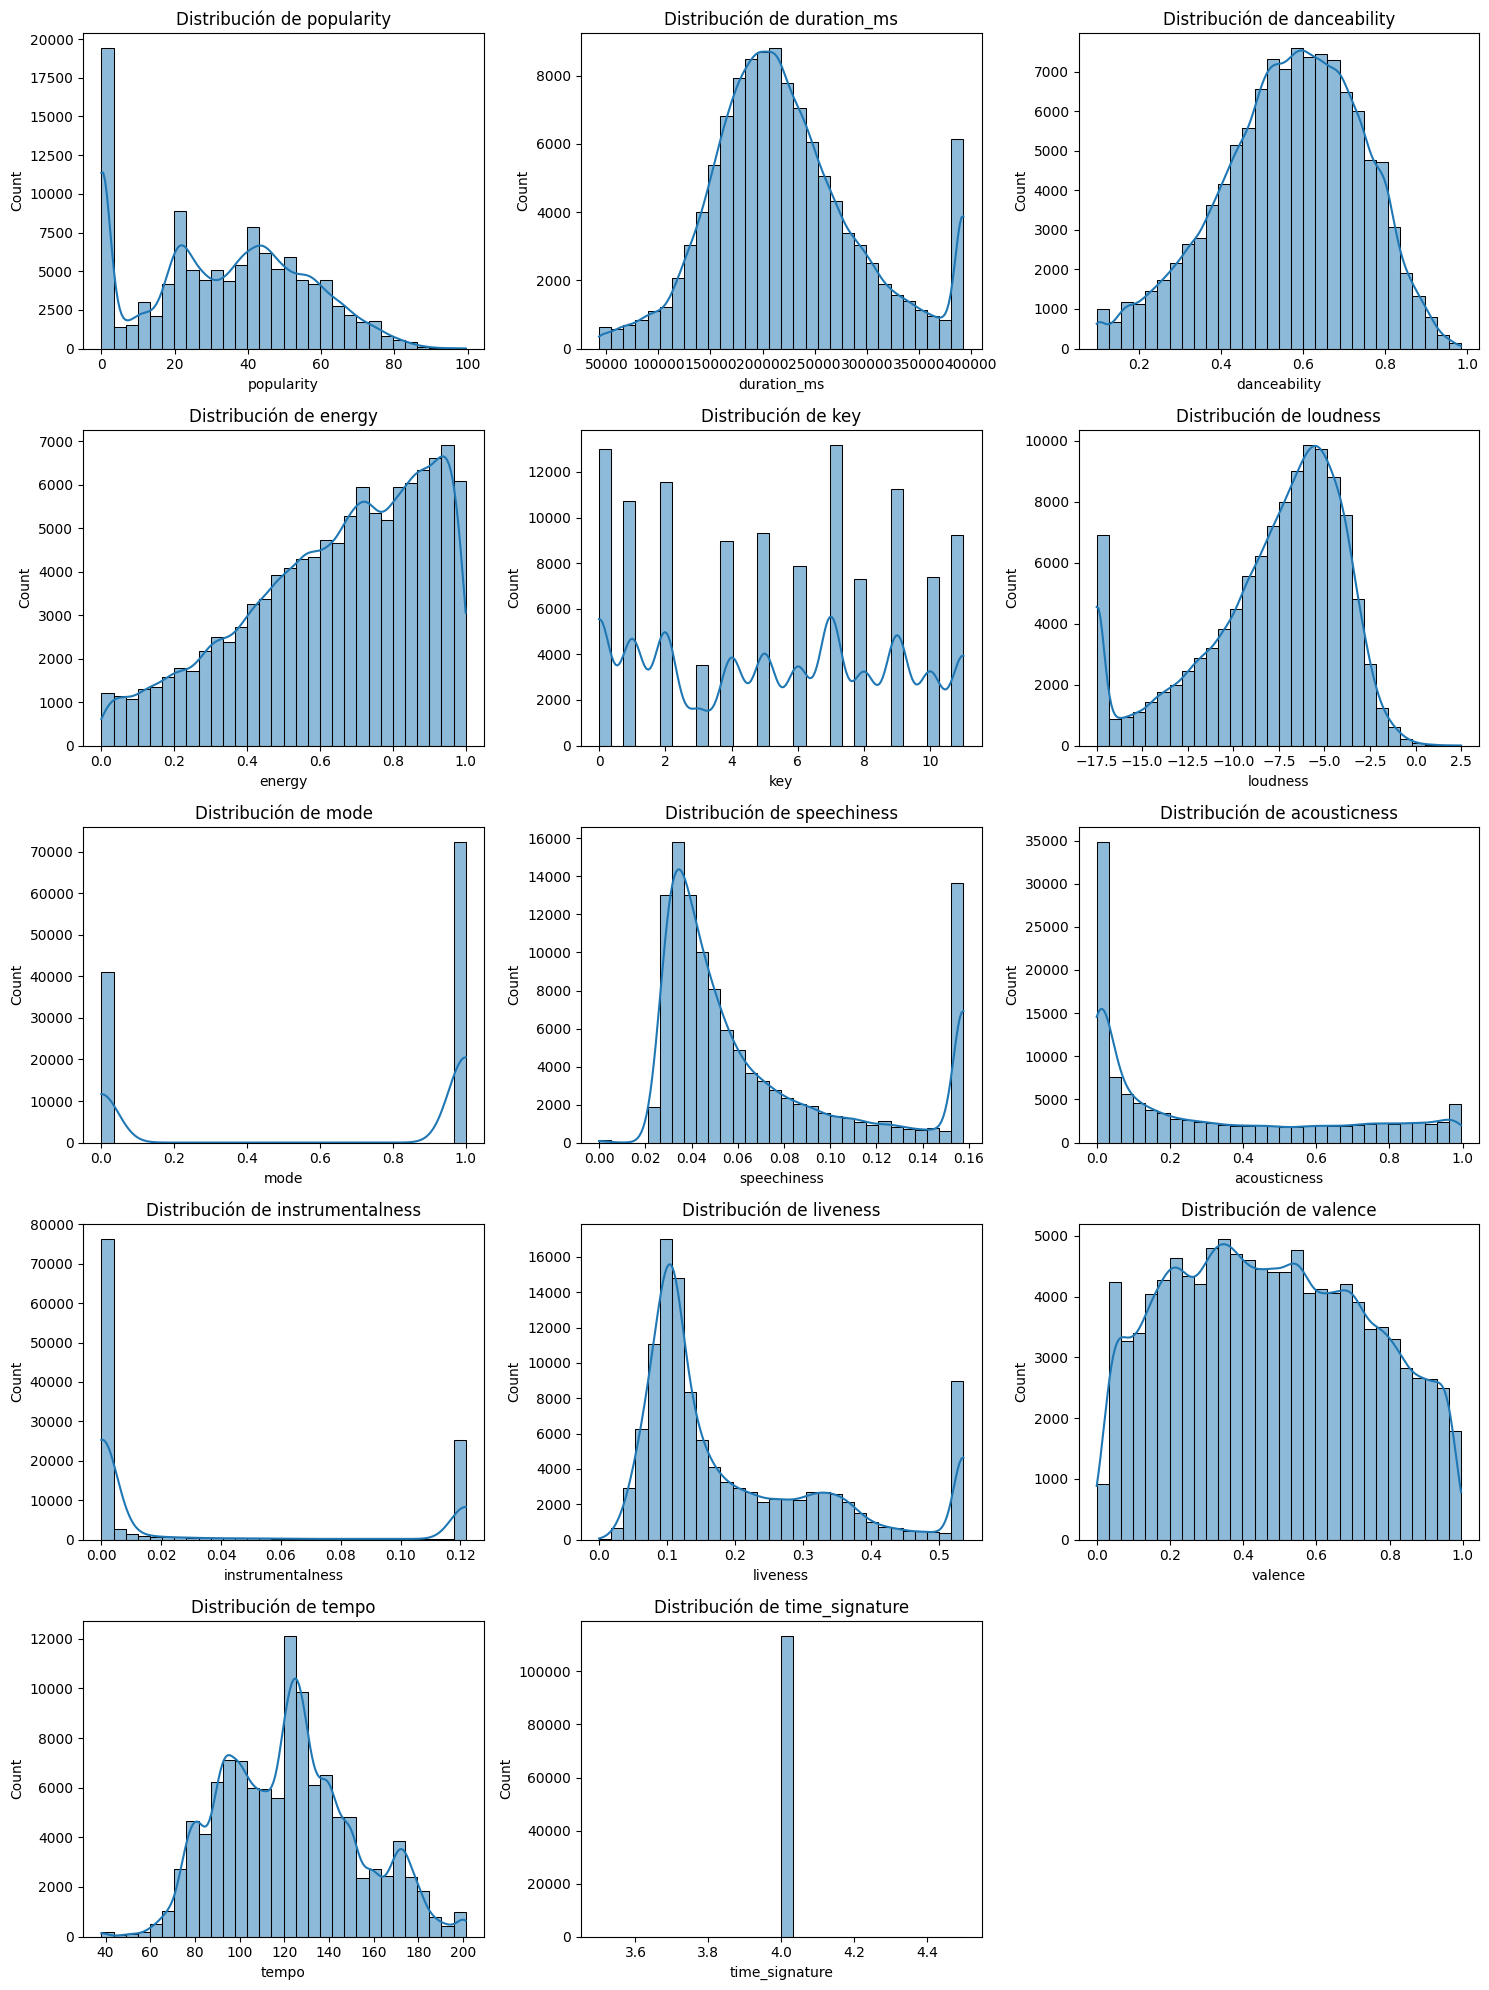

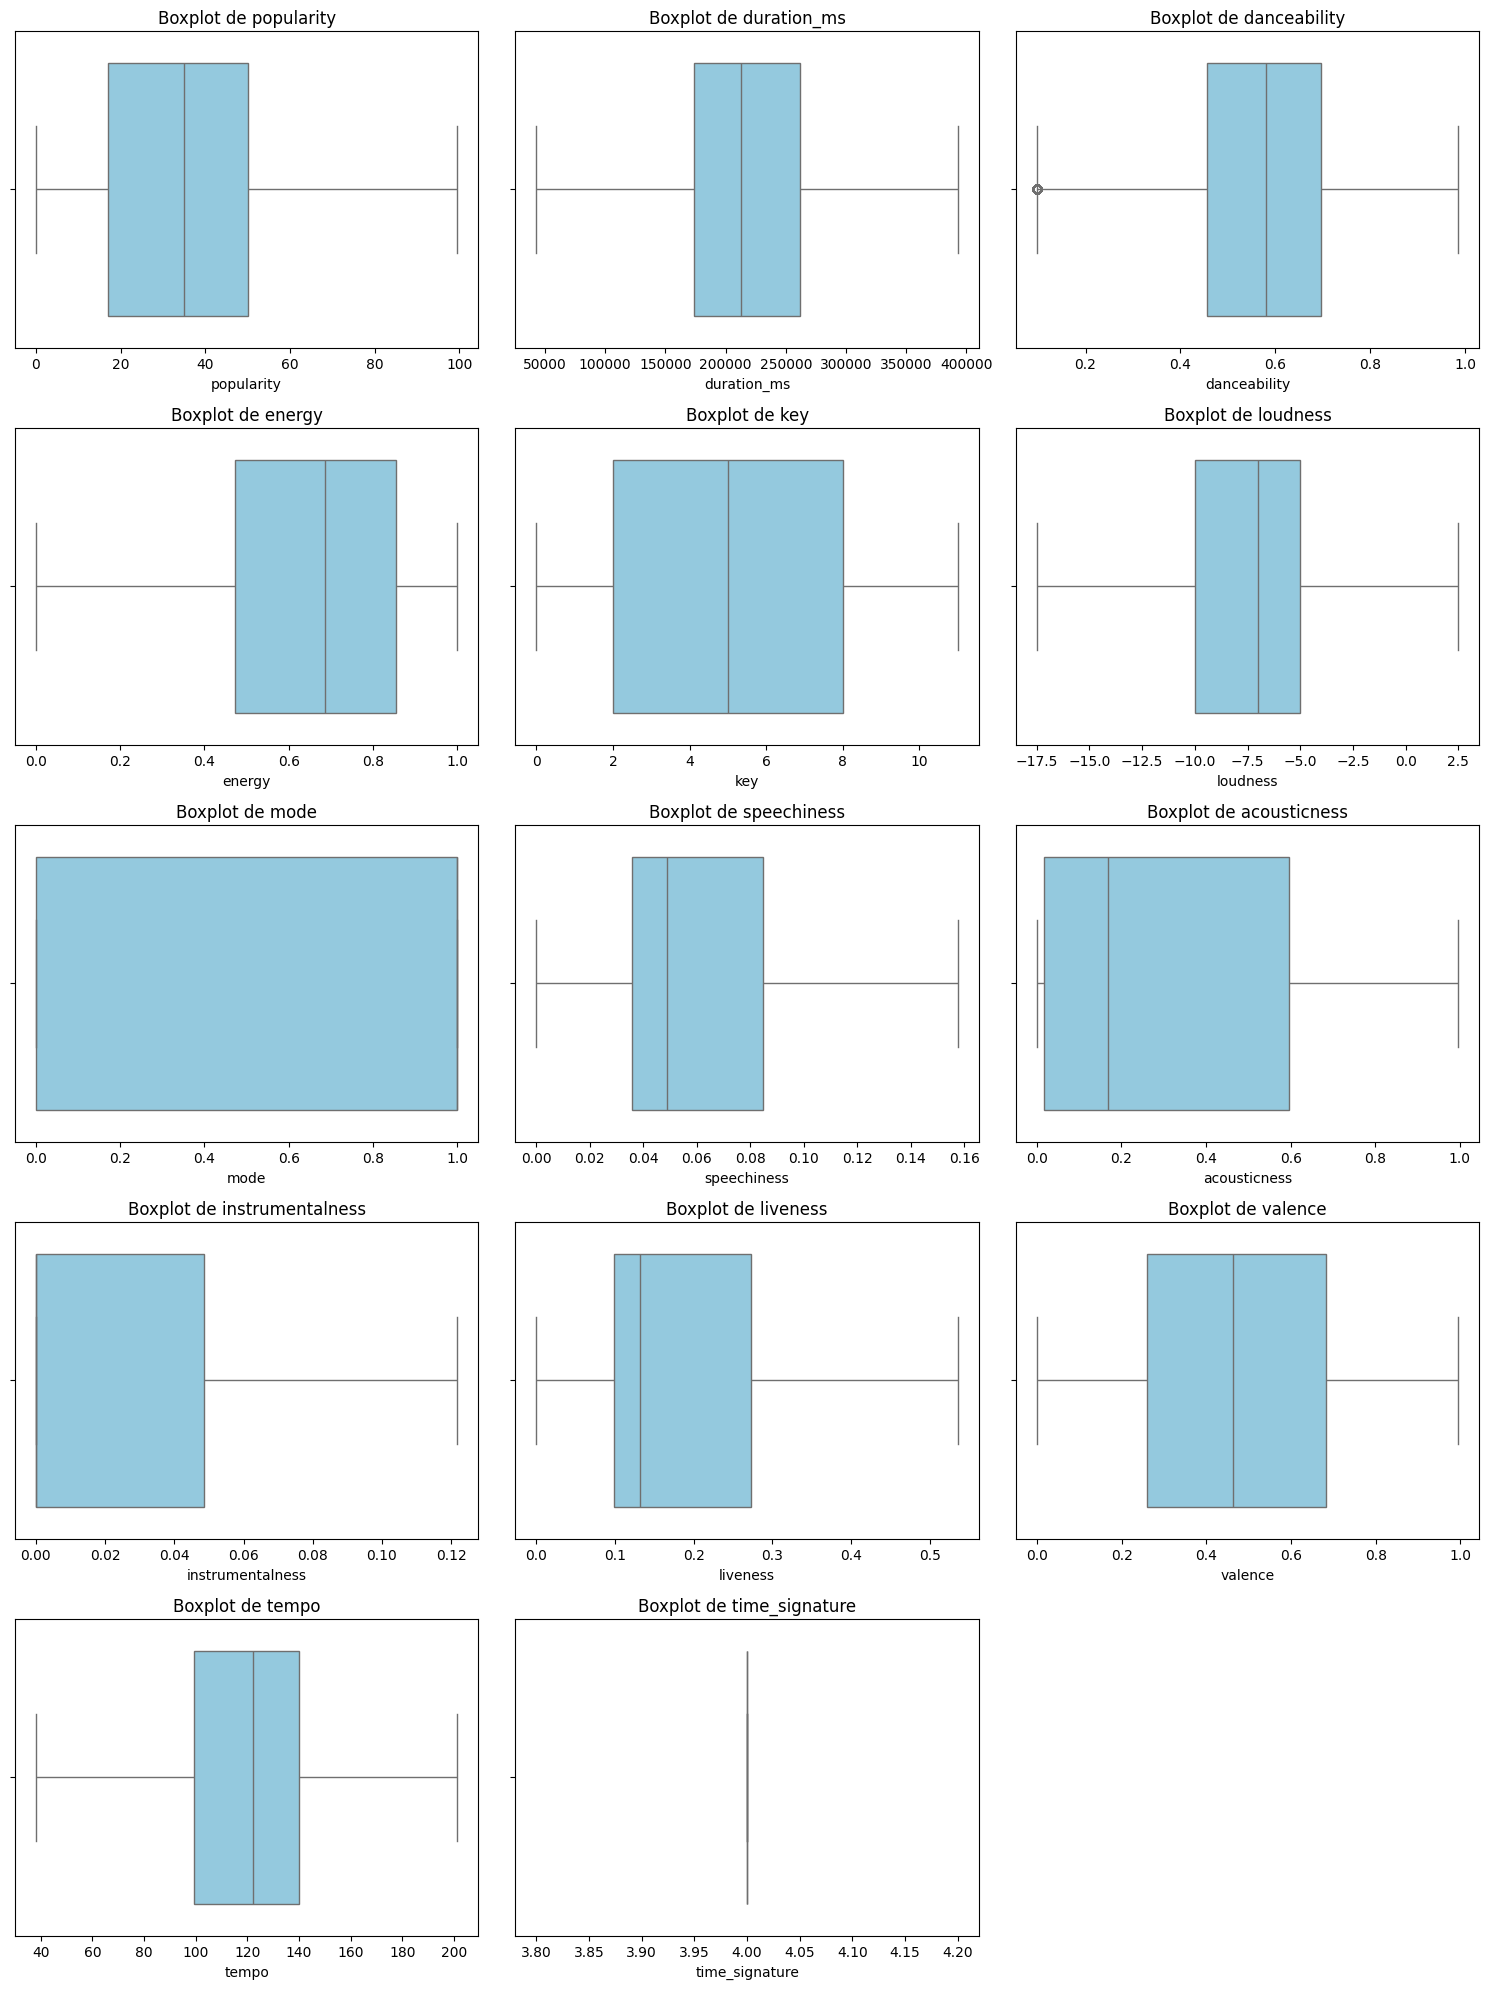

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


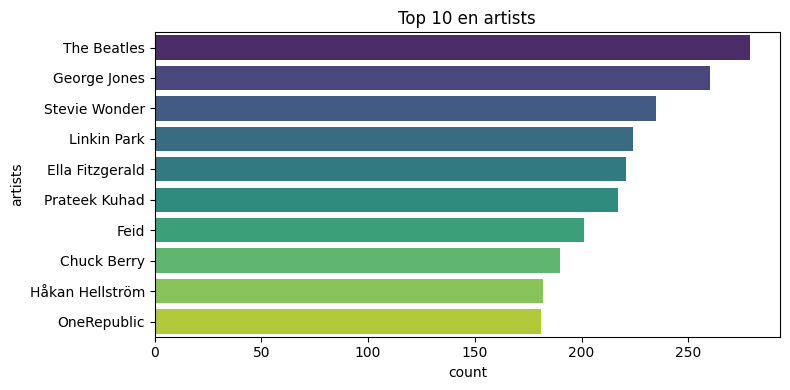

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


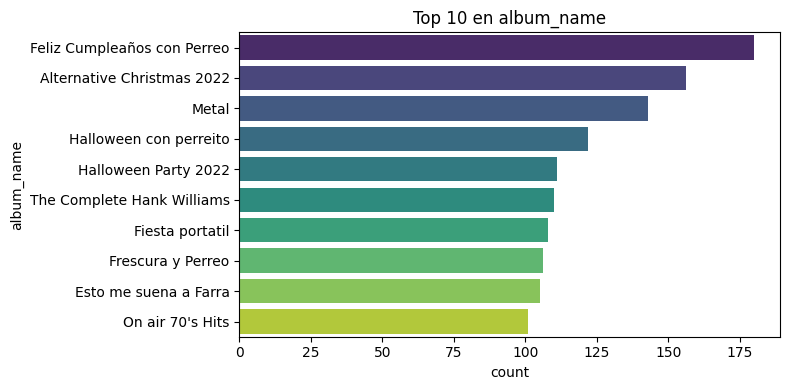

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


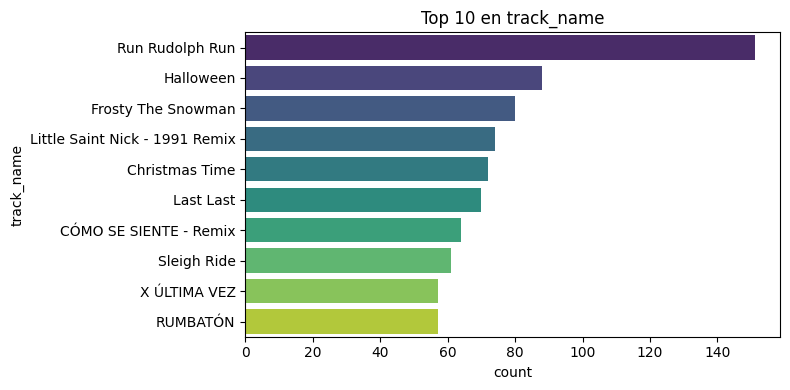

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


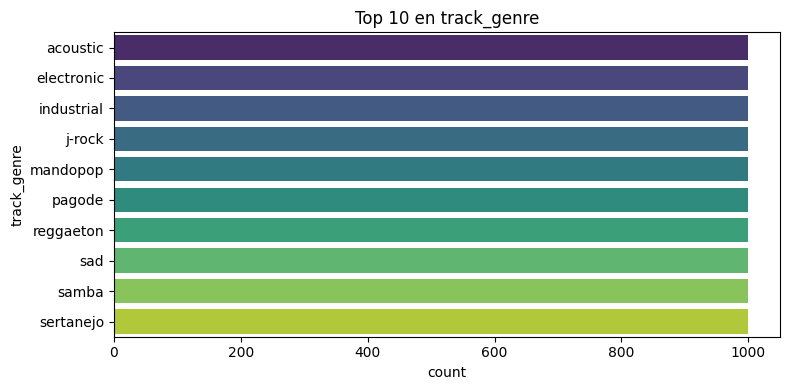

In [10]:
from utils.vis_descriptiva import (
    graficar_distribuciones_numericas,
    graficar_categoricas,
    graficar_boxplots
)

graficar_distribuciones_numericas(df)
graficar_boxplots(df)
graficar_categoricas(df)